<a href="https://colab.research.google.com/github/szelld/monkey_stack_deeplearning/blob/2-Bead%C3%A1s/Skin_Cancer_Detection_Milestone_2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We have chosen the **ISIC 2024 - Skin Cancer Detection task with 3D-TBP**, and this is our second milestone.
You can find the problem and the dataset we used [here](https://www.kaggle.com/competitions/isic-2024-challenge). In this milestone, we have loaded the necessary data, converted it to the appropriate format and scaled, and set up a data generator, among other steps. Please find detailed explanations and code below.

First we import the necessary libraries

In [1]:
%tensorflow_version 2.x  # this line is not required unless you are in a notebook
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import os
import numpy as np
import tensorflow as tf
import pandas as pd
keras = tf.keras

import h5py
import shutil
from PIL import Image
import io
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


###About tranfroming the Dataset
We downloaded the dataset, extracted it, and formatted it appropriately before compressing it again and uploading it to Google Drive. The code here simply downloads the pre-structured ZIP file from Drive and extracts it. If you'd like to review the steps we followed to structure the data, you can find them in the **milestone_1** notebook. For better readability, we’ve kept only the essential files in this notebook.

### About the structure

This code will unzip the file, which may take some time, and will create two folders: one named "benign," which contains images of non-cancerous moles, and the other named "malignant," which contains images of cancerous moles in a folder called Organized_Dataset.

In [2]:
# Install gdown if you haven't already
!pip install gdown

# File ID from the provided link
file_id = '1UlGjhWlDpL9nIT0CdyJGnMxCJc5VZuCx'
download_link = f'https://drive.google.com/uc?id={file_id}'

# Download the ZIP file
!gdown --id {file_id} --output dataset.zip

# Create a folder for the organized dataset
!mkdir Organized_Dataset

# Unzip the downloaded file into the Organized_Dataset folder
!unzip dataset.zip -d Organized_Dataset

A streamkimeneten csak az utolsó 5000 sor látható.
  inflating: Organized_Dataset/benign/ISIC_1399219.jpg  
  inflating: Organized_Dataset/benign/ISIC_0632500.jpg  
  inflating: Organized_Dataset/benign/ISIC_2725785.jpg  
  inflating: Organized_Dataset/benign/ISIC_7632164.jpg  
  inflating: Organized_Dataset/benign/ISIC_6491430.jpg  
  inflating: Organized_Dataset/benign/ISIC_5811800.jpg  
  inflating: Organized_Dataset/benign/ISIC_7078164.jpg  
  inflating: Organized_Dataset/benign/ISIC_5460061.jpg  
  inflating: Organized_Dataset/benign/ISIC_8336137.jpg  
  inflating: Organized_Dataset/benign/ISIC_6265352.jpg  
  inflating: Organized_Dataset/benign/ISIC_7430767.jpg  
  inflating: Organized_Dataset/benign/ISIC_7746968.jpg  
  inflating: Organized_Dataset/benign/ISIC_7739668.jpg  
  inflating: Organized_Dataset/benign/ISIC_2178954.jpg  
  inflating: Organized_Dataset/benign/ISIC_0172797.jpg  
  inflating: Organized_Dataset/benign/ISIC_6941272.jpg  
  inflating: Organized_Dataset/benign

The code below selects 10% of the images from each dataset category and moves them into new directories labeled with "_test." This step is essential for creating a dedicated test dataset, ensuring these images are separated from the original folders for more effective model evaluation.


In [3]:
def move_percentage_of_files(src_folder, dest_folder, percentage=0.1):
    # Create the destination folder if it doesn't exist
    os.makedirs(dest_folder, exist_ok=True)

    # Get all files in the source directory
    files = os.listdir(src_folder)
    files = [f for f in files if os.path.isfile(os.path.join(src_folder, f))]

    # Calculate number of files to move
    num_files_to_move = int(len(files) * percentage)

    # Randomly select files to move
    files_to_move = random.sample(files, num_files_to_move)

    # Move files
    for file_name in files_to_move:
        src_path = os.path.join(src_folder, file_name)
        dest_path = os.path.join(dest_folder, file_name)
        shutil.move(src_path, dest_path)
    print(f"Moved {num_files_to_move} files from {src_folder} to {dest_folder}.")

# Paths
benign_folder = 'Organized_Dataset/benign'
benign_test_folder = 'Test/benign_test'
malignant_folder = 'Organized_Dataset/malignant'
malignant_test_folder = 'Test/malignant_test'

# Move 10% of the images
move_percentage_of_files(benign_folder, benign_test_folder, percentage=0.1)
move_percentage_of_files(malignant_folder, malignant_test_folder, percentage=0.1)


Moved 40066 files from Organized_Dataset/benign to Test/benign_test.
Moved 39 files from Organized_Dataset/malignant to Test/malignant_test.



### One of the key Idea of our solution
This code below addresses the challenge of dataset imbalance in the ISIC 2024 competition by augmenting malignant (cancerous) images and creating balanced training batches. The augment_malignant_images function uses data augmentation techniques like rotations, flips, and zooms to generate a target number of diverse malignant samples, mitigating their scarcity.  By balancing and diversifying the dataset, the code helps train a robust model for cancerous mole detection.
Note: It will create a new folder with the augmented images

In [4]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augment malignant images to create 5000 augmented samples
def augment_malignant_images(malignant_dir, augmented_dir, target_size=(128, 128), target_augmented_count=5000):
    os.makedirs(augmented_dir, exist_ok=True)
    malignant_aug = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    original_malignant_images = os.listdir(malignant_dir)
    augmented_count = 0

    for img_name in original_malignant_images:
        img_path = os.path.join(malignant_dir, img_name)
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        for batch in malignant_aug.flow(img_array, batch_size=1, save_to_dir=augmented_dir, save_prefix='aug', save_format='jpeg'):
            augmented_count += 1
            if augmented_count >= target_augmented_count:
                return


# Paths for data
data_dir = 'Organized_Dataset'
malignant_folder = os.path.join(data_dir, 'malignant')
augmented_malignant_folder = os.path.join(data_dir, 'augmented_malignant')
benign_folder = os.path.join(data_dir, 'benign')

# Run the augmentation function
augment_malignant_images(malignant_folder, augmented_malignant_folder)


This code block below calculates and displays the number of images in each category (benign, malignant, and augmented malignant). This helps us understand the size of our dataset and ensure we have balanced data for both classes before proceeding with training.

In [5]:
import os

# Paths to your image folders
benign_folder = 'Organized_Dataset/benign'
malignant_folder = 'Organized_Dataset/malignant'
augmented_malignant_folder = 'Organized_Dataset/augmented_malignant'

# Get the number of images in each folder
num_benign = len(os.listdir(benign_folder))
num_malignant = len(os.listdir(malignant_folder))
num_augmented_malignant = len(os.listdir(augmented_malignant_folder))

# Print the sizes of the libraries
print(f"Size of benign library: {num_benign} images")
print(f"Size of malignant library: {num_malignant} images")
print(f"Size of augmented malignant library: {num_augmented_malignant} images")

Size of benign library: 360600 images
Size of malignant library: 354 images
Size of augmented malignant library: 3912 images


This section prepares the training dataset by copying all original malignant images and an equal number of benign images into a train_folder. Additionally, it includes the augmented malignant images in the malignant subset of the train_data folder to ensure enough malignant samples, creating a balanced and ready-to-use training set.

In [6]:
import os
import random
import shutil

# Define paths to your image folders
augmented_malignant_folder = 'Organized_Dataset/augmented_malignant'
benign_folder = 'Organized_Dataset/benign'
malignant_folder = 'Organized_Dataset/malignant'
train_folder = 'train_data'  # Create a new folder for the training data

# Create the train folder if it doesn't exist
os.makedirs(train_folder, exist_ok=True)
os.makedirs(os.path.join(train_folder, 'benign'), exist_ok=True)
os.makedirs(os.path.join(train_folder, 'malignant'), exist_ok=True)

# move all of the original malignant images into the training data
for img in os.listdir(malignant_folder):
    shutil.copy(os.path.join(malignant_folder, img), os.path.join(train_folder, 'malignant', img))


# Get the number of augmented malignant images
num_needed = len(os.listdir(augmented_malignant_folder)) + len(os.listdir(malignant_folder))

# Randomly select an equal number of benign images
benign_images = os.listdir(benign_folder)
selected_benign = random.sample(benign_images, num_needed)

# Copy the selected benign images to the train folder
for image_name in selected_benign:
    src_path = os.path.join(benign_folder, image_name)
    dest_path = os.path.join(train_folder, 'benign', image_name)
    shutil.copy(src_path, dest_path)

# Copy the augmented malignant images to the train folder
for image_name in os.listdir(augmented_malignant_folder):
    src_path = os.path.join(augmented_malignant_folder, image_name)
    dest_path = os.path.join(train_folder, 'malignant', image_name)
    shutil.copy(src_path, dest_path)

train_benign_folder = 'train_data/benign'
print(f"Training dataset created with {num_malignant} malignant and {len(os.listdir(train_benign_folder))} benign images.")

Training dataset created with 354 malignant and 4266 benign images.


This code uses ImageDataGenerator to normalize the images and apply transformations (like rotation, shifting, and zooming) to add variety to the data. It also splits the data into training and validation sets, providing a structured and robust setup for model training and evaluation.

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the path to your training data folder
train_folder = 'train_data'

# Create an ImageDataGenerator instance with only rescaling (no augmentation)
train_datagen = ImageDataGenerator(
         rescale=1./255,
         rotation_range=20,  # Rotate images by up to 20 degrees
         width_shift_range=0.2,  # Shift images horizontally by up to 20% of the width
         height_shift_range=0.2,  # Shift images vertically by up to 20% of the height
         shear_range=0.2,  # Apply shear transformations
         zoom_range=0.2,  # Zoom in or out on images
         horizontal_flip=True,  # Flip images horizontally
         fill_mode='nearest',  # Fill in missing pixels
         validation_split=0.2  # Split data into training and validation sets
     )

# Create a flow_from_directory for the training data
train_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=True,
    subset='training'  # Specify 'training' subset
)

# Create a flow_from_directory for the validation data
validation_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False,  # No need to shuffle validation data
    subset='validation'  # Specify 'validation' subset
)




Found 6826 images belonging to 2 classes.
Found 1706 images belonging to 2 classes.


Here, random seeds are set for Python, NumPy, and TensorFlow to ensure reproducibility. This step is essential for consistent results across runs, especially for model training and evaluation.

In [8]:
import tensorflow as tf
import random
import os
import numpy as np

# Set random seeds for Python, NumPy, and TensorFlow
os.environ['PYTHONHASHSEED'] = str(42)  # Set environment variable for Python hash seed
random.seed(42)  # Set seed for Python random module
np.random.seed(42)  # Set seed for NumPy random module
tf.random.set_seed(42)  # Set seed for TensorFlow random operations

### Let's build and train our model
This code below defines and trains a deep learning model for binary image classification (benign vs. malignant) using the EfficientNetV2L architecture as the base, which is pre-trained on ImageNet. It first trains the model with frozen base layers, adds custom top layers for classification, and uses callbacks like ModelCheckpoint and EarlyStopping to save the best model and prevent overfitting. After initial training, the last few layers of the base model are unfrozen and fine-tuned to improve the model’s performance. This process is crucial for adapting a pre-trained model to our specific problem, ensuring accuracy, and preventing overfitting, ultimately resulting in a  model that can be used for classifying
 medical images effectively.
 note: We are also planning to extend this model with a prediction, based on data about the images located in the provided .csv file on the kaggle website for better accuracy.

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import Recall

# Define the model with EfficientNetV2L as base
def build_model():
    base_model = EfficientNetV2L(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = False  # Freeze base model

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall()]
    )
    return model

# Initialize the model
model = build_model()

# Define callbacks
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# Unfreeze last few layers for fine-tuning
for layer in model.layers[0].layers[-10:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall()]
)

# Fine-tune the model
history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# Save final model
model.save('final_model.keras')

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


214/214 ━━━━━━━━━━━━━━━━━━━━ 256s 708ms/step - accuracy: 0.5701 - loss: 0.6897 - recall: 0.6128 - val_accuracy: 0.6413 - val_loss: 0.6347 - val_recall: 0.8746
Epoch 2/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 56s 257ms/step - accuracy: 0.6398 - loss: 0.6475 - recall: 0.6734 - val_accuracy: 0.6870 - val_loss: 0.5926 - val_recall: 0.8124
Epoch 3/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 52s 237ms/step - accuracy: 0.6915 - loss: 0.5961 - recall: 0.7089 - val_accuracy: 0.6694 - val_loss: 0.5942 - val_recall: 0.8242
Epoch 4/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 59s 273ms/step - accuracy: 0.6918 - loss: 0.5931 - recall: 0.7153 - val_accuracy: 0.7175 - val_loss: 0.5715 - val_recall: 0.7386
Epoch 5/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 75s 242ms/step - accuracy: 0.7266 - loss: 0.5610 - recall: 0.7626 - val_accuracy: 0.7163 - val_loss: 0.5633 - val_recall: 0.7573
Epoch 6/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 57s 264ms/step - accuracy: 0.7413 - loss: 0.5349 - recall: 0.7679 - val_accuracy: 0.7327 - val_loss: 0.5876 - val_recall: 0.6

### Let's test and evaluate our model
This code prepares the test dataset by creating an ImageDataGenerator with rescaling applied to normalize pixel values. It then loads the test images from the specified directory. Afterward, the model is evaluated on the test dataset, and metrics like loss, accuracy, and recall are printed to assess the model's performance. This evaluation step is crucial for determining how well the model generalizes to new, unseen data, providing insights into its real-world performance.
Note: The test data is not balanced to make it represent real-word data better.

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator for the test data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create a flow_from_directory for the test data
test_generator = test_datagen.flow_from_directory(
    'Test',  # Path to your 'Test' folder
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important: Do not shuffle test data
)

# Evaluate the model on the test data
loss, accuracy, recall = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Recall: {recall:.4f}")

Found 40105 images belonging to 2 classes.
1254/1254 ━━━━━━━━━━━━━━━━━━━━ 148s 118ms/step - accuracy: 0.7073 - loss: 0.4954 - recall_1: 9.4596e-04
Test Loss: 0.4990
Test Accuracy: 0.7060
Test Recall: 0.4103


### Download the trained model
You can simply download our trained model with the code block below, you do not need to train it yourself. This method makes it easy to try our model out and test it's capabilities.

In [17]:
import gdown
from tensorflow.keras.models import load_model

# Google Drive link to the model file
url = 'https://drive.google.com/uc?id=1EWi0MNblQo4b9qF0gXDjWPOTBH0f0Oc6'

# Path to save the downloaded model
output_path = 'trained_model.keras'

# Download the model from Google Drive
gdown.download(url, output_path, quiet=False)

# Load the trained model
model = load_model(output_path)

# Verify by printing the model summary
model.summary()

Downloading...
From (original): https://drive.google.com/uc?id=1EWi0MNblQo4b9qF0gXDjWPOTBH0f0Oc6
From (redirected): https://drive.google.com/uc?id=1EWi0MNblQo4b9qF0gXDjWPOTBH0f0Oc6&confirm=t&uuid=bde3d58e-4bce-469a-88f4-00b8609a26cd
To: /content/trained_model.keras
100%|██████████| 513M/513M [00:13<00:00, 37.1MB/s]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)        │ (None, 4, 4, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 127,266,021 (485.48 MB)

 Trainable params: 4,677,537 (17.84 MB)

 Non-trainable params: 113,233,408 (431.95 MB)

 Optimizer params: 9,355,076 (35.69 MB)

This code calculates and visualizes the confusion matrix for the model's predictions on the test dataset. This is crucial for understanding how well the model performs across different classes, particularly in terms of false positives and false negatives. This representation is effective because it is easy to comprehend for the human eye.

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 127s 102ms/step


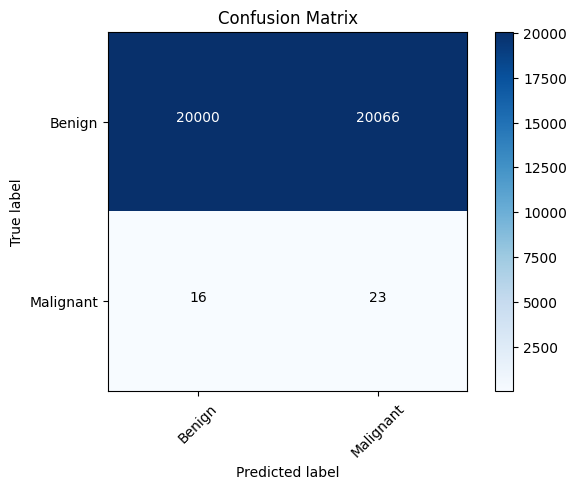

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get the true labels and predicted labels for the test data
y_true = test_generator.classes  # True labels
y_pred = model.predict(test_generator)  # Predicted probabilities
y_pred_classes = (y_pred > 0.3).astype(int)  # Convert probabilities to class labels (0 or 1)

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Define class labels for the confusion matrix
class_labels = ['Benign', 'Malignant']

# Function to plot the confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, class_labels)

This code block below evaluates the model, based on the Kaggle competion evaluation metrics.

In [20]:
from sklearn.metrics import roc_curve, auc

def calculate_pauc(y_true, y_pred, tpr_threshold=0.8):
    """Calculates the partial AUC (pAUC) above a given TPR threshold.

    Args:
        y_true: True labels (0 or 1).
        y_pred: Predicted probabilities for the positive class.
        tpr_threshold: The minimum TPR value to consider for pAUC calculation.

    Returns:
        The pAUC value.
    """

    fpr, tpr, thresholds = roc_curve(y_true, y_pred)

    # Find the index where TPR is closest to the threshold
    idx = np.argmax(tpr >= tpr_threshold)

    # Calculate pAUC using trapezoidal rule
    pauc_score = auc(fpr[idx:], tpr[idx:])

    return pauc_score

# Assuming you have your model predictions in `y_pred` and true labels in `y_true`
y_true = test_generator.classes  # True labels from your test generator
y_pred = model.predict(test_generator).ravel()  # Predicted probabilities

pauc = calculate_pauc(y_true, y_pred, tpr_threshold=0.8)

print(f"Partial AUC above 80% TPR: {pauc}")

1254/1254 ━━━━━━━━━━━━━━━━━━━━ 124s 99ms/step
Partial AUC above 80% TPR: 0.27066558127807067
